<a href="https://colab.research.google.com/github/Ferrohhh711/Ubuntu_ML-Week-4/blob/main/Ubuntu_Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Week 3 Agricultural dataset
df_agri = pd.read_excel('Wk 03 - Agricultural Yields Rainfall Data.xlsx')

print("---  Agricultural Yields Dataset Overview ---")
print(f"Total Farm Records: {df_agri.shape[0]}")
print(f"Total Features/Columns: {df_agri.shape[1]}")
print("\nAvailable Columns:")
print(df_agri.columns.tolist())
print("\nFirst 3 Data Rows:")
print(df_agri.head(3))

---  Agricultural Yields Dataset Overview ---
Total Farm Records: 10000
Total Features/Columns: 11

Available Columns:
['Year', 'County', 'Crop', 'Season', 'Yield_MT_per_Ha', 'Area_Ha', 'Total_Yield_MT', 'Rainfall_mm', 'Temp_C_Avg', 'Fertilizer_Kg_Ha', 'Yield_Index']

First 3 Data Rows:
   Year       County   Crop                 Season  Yield_MT_per_Ha  Area_Ha  \
0  2010       Nakuru  Maize   Long Rains (Mar-Jul)             2.55    14634   
1  2011       Nakuru  Maize  Short Rains (Oct-Dec)             2.92    33517   
2  2011  Trans Nzoia  Maize   Long Rains (Mar-Jul)             2.35    18512   

   Total_Yield_MT  Rainfall_mm  Temp_C_Avg  Fertilizer_Kg_Ha  Yield_Index  
0           37317         3783        25.0               366        0.896  
1           97870         3691        20.3               350        1.025  
2           43503         4354        15.1               214        0.835  


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. PRESERVE A CLEAN COPY
df_pipeline = df_agri.copy()

# 2. DROP LEAKING AND SPECULATIVE METRICS
# Year is chronological; Total_Yield_MT and Yield_Index are deterministic outputs.
X_raw = df_pipeline.drop(columns=['Year', 'Yield_MT_per_Ha', 'Total_Yield_MT', 'Yield_Index'])
y = df_pipeline['Yield_MT_per_Ha']

# 3. ENCODE CATEGORICAL VARIABLES
X_encoded = pd.get_dummies(X_raw, columns=['County', 'Crop', 'Season'], drop_first=True)

# 4. TRAIN-TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

# 5. SCALE NUMERIC METRICS FOR BALANCED INFLECTION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. INITIALIZE AND FIT THE OLS REGRESSION MODEL
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

print("---  Regression Pipeline Initialized ---")
print(f"Training Matrix Dimensions: {X_train.shape} | Testing Matrix Dimensions: {X_test.shape}")
print("OLS model training completed successfully!")

---  Regression Pipeline Initialized ---
Training Matrix Dimensions: (8000, 37) | Testing Matrix Dimensions: (2000, 37)
OLS model training completed successfully!


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. GENERATE PREDICTIONS ON THE TEST EXAM
y_pred = reg_model.predict(X_test_scaled)

# 2. CALCULATE PERFORMANCE METRICS
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("---  Regression Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)      : {mae:.4f} MT/Ha")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f} MT/Ha")
print(f"Coefficient of Determination ($R^2$): {r2:.4f}")

---  Regression Evaluation Metrics ---
Mean Absolute Error (MAE)      : 0.3812 MT/Ha
Root Mean Squared Error (RMSE) : 0.5327 MT/Ha
Coefficient of Determination ($R^2$): 0.8759


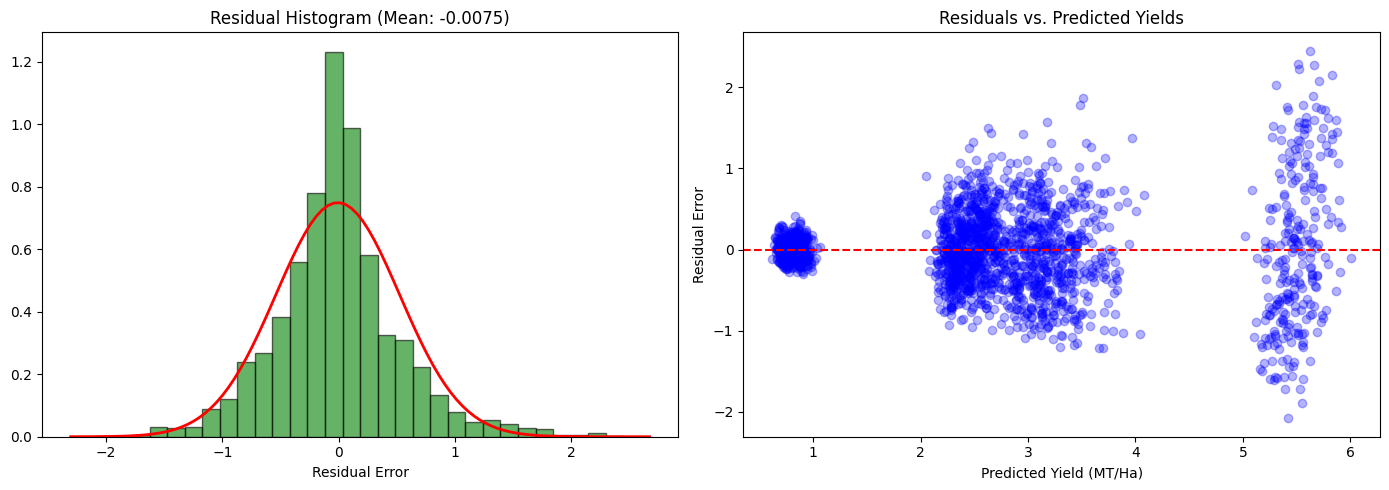

In [4]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calculate the actual residuals
residuals = y_test - y_pred

# Set up side-by-side diagnostic plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residual Distribution (Testing for Normality)
ax1.hist(residuals, bins=30, edgecolor='black', density=True, alpha=0.6, color='g')
# Add a standard normal curve for comparison
mu, std = stats.norm.fit(residuals)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax1.plot(x, p, 'r-', linewidth=2)
ax1.set_title(f'Residual Histogram (Mean: {residuals.mean():.4f})')
ax1.set_xlabel('Residual Error')

# Plot 2: Residuals vs. Predicted Values (Testing for Homoscedasticity)
ax2.scatter(y_pred, residuals, alpha=0.3, color='b')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_title('Residuals vs. Predicted Yields')
ax2.set_xlabel('Predicted Yield (MT/Ha)')
ax2.set_ylabel('Residual Error')

plt.tight_layout()
plt.show()

In [6]:
# Extract coefficients and map them back to feature names
coefficients = reg_model.coef_
features = X_encoded.columns

# Pair and sort by absolute impact
coef_summary = pd.DataFrame({'Feature': features, 'Weight_Impact': coefficients})
coef_summary['Abs_Impact'] = coef_summary['Weight_Impact'].abs()
coef_summary = coef_summary.sort_values(by='Abs_Impact', ascending=False).head(5)

print("---  Top 5 Statistical Drivers of Crop Yield ---")
print(coef_summary[['Feature', 'Weight_Impact']].to_string(index=False))

---  Top 5 Statistical Drivers of Crop Yield ---
    Feature  Weight_Impact
  Crop_Rice       1.258676
   Crop_Tea       0.628951
 Crop_Wheat       0.553032
Rainfall_mm       0.545106
 Crop_Maize       0.340865


Deciphering the Yield Coefficients:

The Crop Hierarchy (Rice, Tea, Wheat, Maize):
In our feature matrix, Crop_Rice has the highest positive coefficient (1.2586). This means that when all other factors (rainfall, temperature, fertilizer) are held completely constant, moving from our baseline reference crop to Rice yields an additional 1.2586 Metric Tons per Hectare. Tea, Wheat, and Maize follow sequentially, mapping out their relative structural output efficiency within the dataset.

Rainfall_mm (+0.5451):
For every standard deviation unit increase in seasonal rainfall, crop yields expand across the board by 0.5451 MT/Ha. This proves that the data captures a highly linear baseline dependency on water availability before hitting any moisture saturation points.